In [1]:
import numpy as np
import pandas as pd

In [2]:

df = pd.read_csv('weight-height.csv')

In [17]:
df['Gender'].value_counts()

Gender
Male      5000
Female    5000
Name: count, dtype: int64

In [18]:
df.shape


(10000, 3)

In [19]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [20]:
import seaborn as sns


/var/folders/69/q9zwcs613054zrngsvhg1p_m0000gn/T/ipykernel_3845/3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

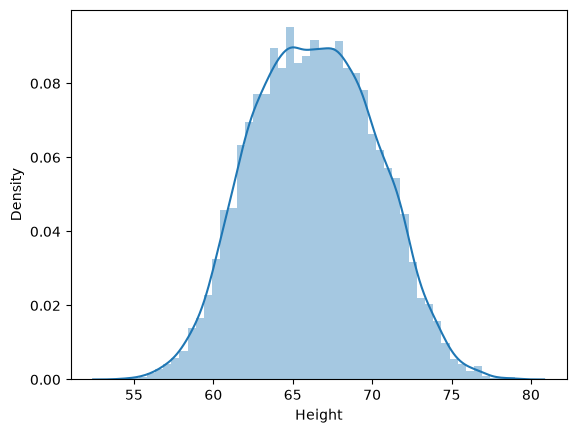

In [24]:
sns.distplot(df['Height'])

In [25]:
df['Height'].skew()

np.float64(0.04936908937689042)

<Axes: ylabel='Height'>

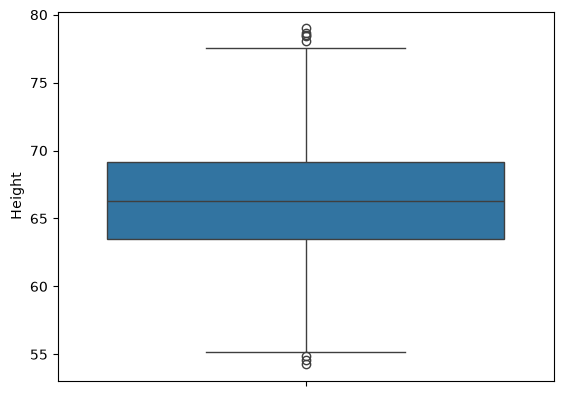

In [26]:
sns.boxplot(df['Height'])

In [27]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [30]:
lower_limit=df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [31]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [32]:
new_df['Height'].skew()

np.float64(0.04256132848776851)

/var/folders/69/q9zwcs613054zrngsvhg1p_m0000gn/T/ipykernel_3845/144369209.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

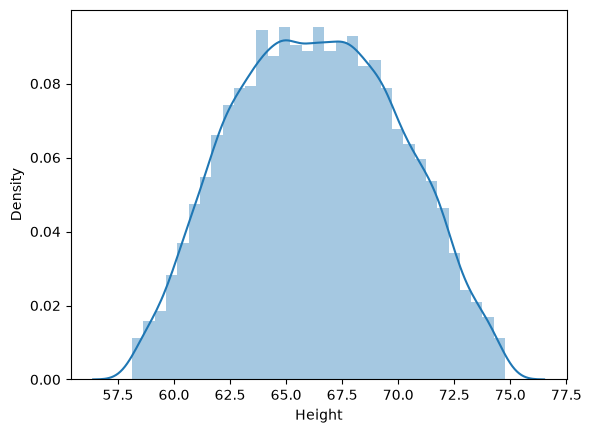

In [33]:

sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

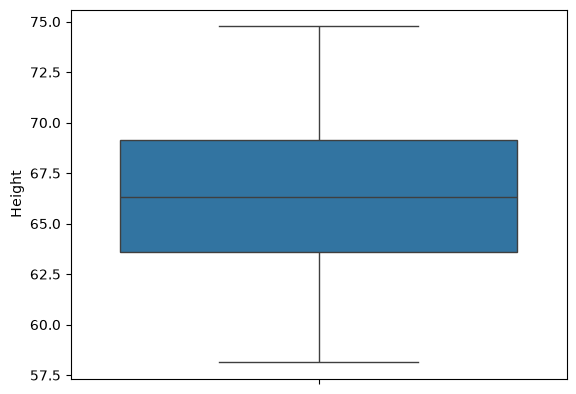

In [34]:
sns.boxplot(new_df['Height'])

In [35]:
# Capping --> Winsorization
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [36]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

In [38]:
df['Height'].skew()

np.float64(0.04315842404657927)

<Axes: ylabel='Height'>

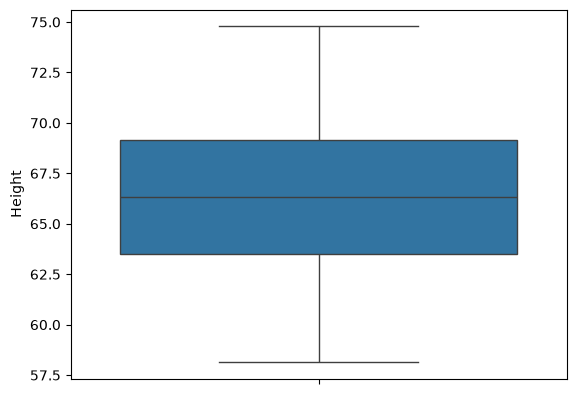

In [39]:
sns.boxplot(df['Height'])

In [41]:
df['Weight'].describe()

count    10000.000000
mean       161.440357
std         32.108439
min         64.700127
25%        135.818051
50%        161.212928
75%        187.169525
max        269.989699
Name: Weight, dtype: float64

In [43]:
upper_limit2 = df['Weight'].quantile(0.99)
df[df['Weight'] > upper_limit2]

,Gender,Height,Weight
0,Male,73.847017,241.893563
23,Male,74.785790,228.761781
82,Male,73.826127,237.916736
190,Male,74.785790,235.035419
191,Male,72.571121,230.560535
...,...,...,...
4577,Male,73.166638,232.761166
4692,Male,73.706027,231.697887
4701,Male,74.785790,241.686601
4721,Male,74.785790,240.440816


In [45]:
percentile25 = df['Weight'].quantile(0.25)
percentile75 = df['Weight'].quantile(0.75)

In [46]:
percentile25, percentile75

(np.float64(135.8180513055015), np.float64(187.16952486868348))

In [48]:
IQR = percentile75 - percentile25
IQR

np.float64(51.35147356318197)

In [50]:
Upper_limit = percentile75 + (1.5 * IQR)
Upper_limit

np.float64(264.19673521345646)

In [51]:
Lower_limit = percentile25 - (1.5 * IQR)
Lower_limit     

np.float64(58.79084096072856)

In [62]:
df[df['Weight']>250]

,Gender,Height,Weight
994,Male,74.78579,255.690835
1610,Male,74.78579,255.863326
2014,Male,74.78579,269.989699
2070,Male,74.78579,252.556689
2971,Male,74.78579,250.317151
3285,Male,74.78579,253.889004
3669,Male,74.78579,251.425051
4331,Male,74.78579,254.209073
